<a href="https://colab.research.google.com/github/c14250143-hub/Portofolio/blob/Social-media-vs-emotion/Riset_TikTok_User.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('TikTok profiles dataset (Public web data).csv')

# Drop irrelevant columns
df = df.drop(columns=['timestamp', 'id', 'top_videos', 'url', 'profile_pic_url', 'create_time'])

# Convert 'is_verified' to a boolean type
df['is_verified'] = df['is_verified'].astype(bool)

# Display the cleaned DataFrame information
print("--- Data Information after Cleaning ---")
print(df.info())

--- Data Information after Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   account_id               1000 non-null   object 
 1   nickname                 1000 non-null   object 
 2   biography                997 non-null    object 
 3   awg_engagement_rate      1000 non-null   float64
 4   comment_engagement_rate  1000 non-null   float64
 5   like_engagement_rate     1000 non-null   float64
 6   bio_link                 191 non-null    object 
 7   is_verified              1000 non-null   bool   
 8   followers                1000 non-null   int64  
 9   following                1000 non-null   int64  
 10  likes                    1000 non-null   int64  
 11  videos_count             1000 non-null   int64  
dtypes: bool(1), float64(3), int64(4), object(4)
memory usage: 87.0+ KB
None


In [2]:
# Statistical summary of numerical columns
print("\n--- Statistical Summary ---")
print(df.describe())


--- Statistical Summary ---
       awg_engagement_rate  comment_engagement_rate  like_engagement_rate  \
count          1000.000000              1000.000000           1000.000000   
mean              0.562932                 0.026569              0.536364   
std               3.222055                 0.140016              3.159788   
min               0.000091                 0.000000              0.000000   
25%               0.012528                 0.000252              0.011791   
50%               0.053558                 0.001203              0.049653   
75%               0.202409                 0.006157              0.189987   
max              63.375000                 2.000000             63.000000   

          followers     following         likes  videos_count  
count  1.000000e+03   1000.000000  1.000000e+03   1000.000000  
mean   1.130869e+05   1136.810000  3.371786e+06    271.942000  
std    6.698270e+05   2072.258891  3.128021e+07    464.261197  
min    1.000000e+00  

In [3]:
# Calculate the average engagement rate
avg_engagement_rate = df['awg_engagement_rate'].mean()
print(f"\nAverage Engagement Rate: {avg_engagement_rate:.4f}")


Average Engagement Rate: 0.5629


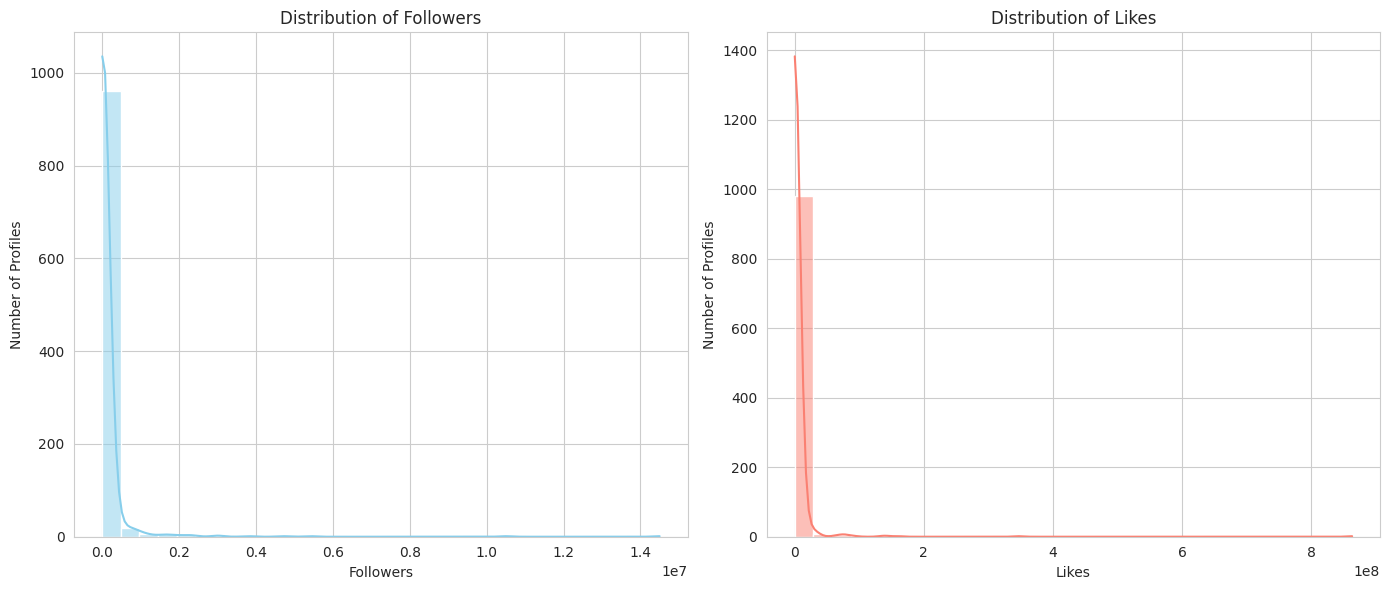

In [4]:
# Set the style for the plots
sns.set_style("whitegrid")

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot the distribution of followers
sns.histplot(df['followers'], bins=30, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Distribution of Followers')
axes[0].set_xlabel('Followers')
axes[0].set_ylabel('Number of Profiles')

# Plot the distribution of likes
sns.histplot(df['likes'], bins=30, ax=axes[1], kde=True, color='salmon')
axes[1].set_title('Distribution of Likes')
axes[1].set_xlabel('Likes')
axes[1].set_ylabel('Number of Profiles')

plt.tight_layout()
plt.show()

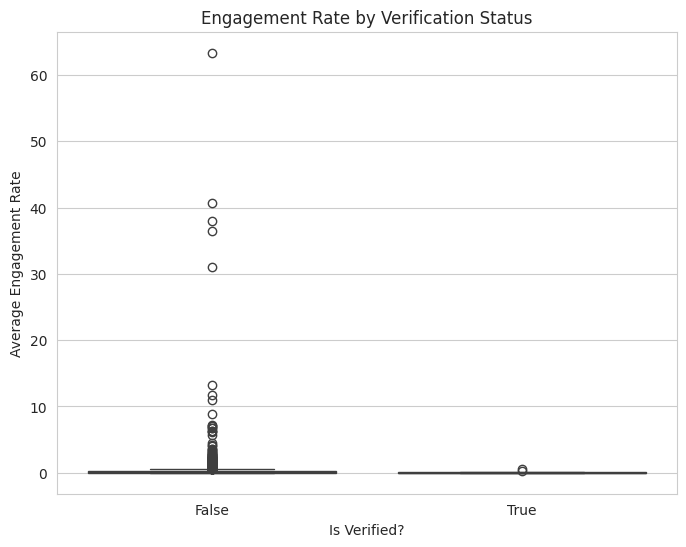

In [5]:
# Boxplot for engagement rate by verification status
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_verified', y='awg_engagement_rate', data=df)
plt.title('Engagement Rate by Verification Status')
plt.xlabel('Is Verified?')
plt.ylabel('Average Engagement Rate')
plt.show()

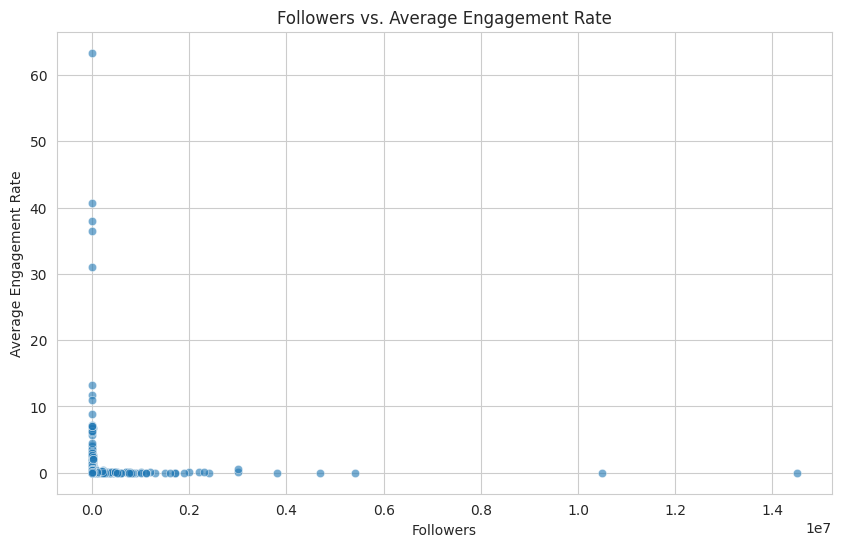


Correlation between Followers and Engagement Rate: -0.0265


In [6]:
# Scatter plot to show the relationship between followers and engagement rate
plt.figure(figsize=(10, 6))
sns.scatterplot(x='followers', y='awg_engagement_rate', data=df, alpha=0.6)
plt.title('Followers vs. Average Engagement Rate')
plt.xlabel('Followers')
plt.ylabel('Average Engagement Rate')
plt.show()

# Calculate and print the correlation coefficient
correlation = df['followers'].corr(df['awg_engagement_rate'])
print(f"\nCorrelation between Followers and Engagement Rate: {correlation:.4f}")

In [7]:
# Sort the DataFrame by followers in descending order and display the top 10
top_10_followers = df.sort_values(by='followers', ascending=False).head(10)
print("\n--- Top 10 Profiles by Followers ---")
print(top_10_followers[['nickname', 'followers', 'awg_engagement_rate']])


--- Top 10 Profiles by Followers ---
             nickname  followers  awg_engagement_rate
759  Nick Smithyman 😎   14500000             0.008123
733   💗 DIANA ASTER 💗   10500000             0.010912
229         Lionsgate    5400000             0.023546
591               Mar    4700000             0.005879
757           Skylarr    3800000             0.009830
811     dukoyasupiste    3000000             0.511269
206    KatjaKrasavice    3000000             0.076421
51              Lylli    2400000             0.018055
832  the.language.boy    2300000             0.157202
554     biteswithlily    2200000             0.160425
